# **Data Merging**

In [3]:
import pandas as pd
import numpy as np

print("Initializing Data Ingestion Pipeline...")

# ==========================================
# 1. LOAD THE DATASETS
# ==========================================
try:
    df1 = pd.read_csv('phishing_site_urls.csv') # Dataset 1
    df2 = pd.read_csv('malicious_and_benign_urls.csv') # Dataset 2
    print(f"Loaded Dataset 1: {df1.shape[0]} rows")
    print(f"Loaded Dataset 2: {df2.shape[0]} rows")
except FileNotFoundError:
    print("CRITICAL ERROR: CSV files not found. Did you upload them to Colab?")
    exit()

# ==========================================
# 2. STANDARDIZE COLUMNS & NORMALIZE LABELS
# We enforce strict binary classification: 0 = Legitimate, 1 = Phishing
# ==========================================

# --- Clean Dataset 1 ---
# Assume DF1 has columns: 'URL', 'Label' (with values 'good'/'bad')
# You must check df1.head() to verify these column names!
df1 = df1.rename(columns={'URL': 'url', 'Label': 'label'}) # Standardize column names
# Map strings to our binary standard
label_mapping_1 = {'good': 0, 'bad': 1}
df1['label'] = df1['label'].map(label_mapping_1)

# --- Clean Dataset 2 ---
# Assume DF2 has columns: 'url', 'type' (with values 'benign', 'phishing', 'malware', 'defacement')
df2 = df2.rename(columns={'type': 'label'})
# In cybersecurity, we treat malware/defacement as malicious (1) alongside phishing
label_mapping_2 = {'benign': 0, 'phishing': 1, 'malware': 1, 'defacement': 1}
df2['label'] = df2['label'].map(label_mapping_2)

# Drop any extraneous columns (we ONLY want 'url' and 'label' right now)
df1 = df1[['url', 'label']]
df2 = df2[['url', 'label']]

# ==========================================
# 3. MERGE & PURGE (Data Leakage Prevention)
# ==========================================
print("\nConcatenating datasets...")
master_df = pd.concat([df1, df2], ignore_index=True)
print(f"Total rows before deduplication: {master_df.shape[0]}")

# Drop rows with missing values
master_df = master_df.dropna()

# THE MOST IMPORTANT LINE OF CODE: Drop duplicate URLs
master_df = master_df.drop_duplicates(subset=['url'], keep='first')
print(f"Total rows AFTER deduplication: {master_df.shape[0]}")

# ==========================================
# 4. SHUFFLE & EXPORT
# ==========================================
# Shuffle the dataset so Legitimate and Phishing are mixed (helps the ML model train evenly)
master_df = master_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the final balance of the dataset
print("\nFinal Dataset Class Distribution:")
print(master_df['label'].value_counts(normalize=True) * 100)

# Export the clean, merged dataset to a new CSV
master_df.to_csv('master_url_dataset.csv', index=False)
print("\nSUCCESS: 'master_url_dataset.csv' created. Ready for Phase A Feature Extraction.")

Initializing Data Ingestion Pipeline...
Loaded Dataset 1: 549346 rows
Loaded Dataset 2: 450176 rows

Concatenating datasets...
Total rows before deduplication: 999522
Total rows AFTER deduplication: 852933

Final Dataset Class Distribution:
label
0.0    86.599416
1.0    13.400584
Name: proportion, dtype: float64

SUCCESS: 'master_url_dataset.csv' created. Ready for Phase A Feature Extraction.


# **Lexical Feature Extraction**
feature_extractor.py

In [6]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
from tqdm import tqdm # For a progress bar

# Enable progress bar for pandas apply
tqdm.pandas()

print("Loading Master Dataset...")
df = pd.read_csv('master_url_dataset.csv')

# Ensure all URLs are strings
df['url'] = df['url'].astype(str)

print("Defining Lexical Extraction Rules...")

def extract_lexical_features(url):
    """
    Takes a raw URL string and extracts numerical features based on
    common phishing patterns.
    """
    features = {}

    # 1. Length features
    features['url_length'] = len(url)

    # 2. Count of suspicious characters
    features['qty_dot'] = url.count('.')
    features['qty_hyphen'] = url.count('-') # Phishers love hyphens (e.g., secure-login-apple.com)
    features['qty_underline'] = url.count('_')
    features['qty_slash'] = url.count('/')
    features['qty_questionmark'] = url.count('?')
    features['qty_equal'] = url.count('=')
    features['qty_at'] = url.count('@') # @ symbol hides the true domain
    features['qty_and'] = url.count('&')
    features['qty_exclamation'] = url.count('!')
    features['qty_space'] = url.count(' ')
    features['qty_tilde'] = url.count('~')
    features['qty_comma'] = url.count(',')
    features['qty_plus'] = url.count('+')
    features['qty_asterisk'] = url.count('*')
    features['qty_hashtag'] = url.count('#')
    features['qty_dollar'] = url.count('$')
    features['qty_percent'] = url.count('%')

    # 3. Domain specific features
    try:
        parsed_url = urlparse(url)
        domain = parsed_url.netloc if parsed_url.netloc else parsed_url.path
        features['domain_length'] = len(domain)
        # Count subdomains (more dots in domain usually means deeper subdomain hiding)
        features['domain_qty_dot'] = domain.count('.')
    except:
        features['domain_length'] = 0
        features['domain_qty_dot'] = 0

    # 4. Check for IP address masquerading as domain
    # e.g., http://192.168.1.1/login.php
    ipv4_pattern = re.compile(r'(([01]?\d\d?|2[0-4]\d|25[0-5])\.){3}([01]?\d\d?|2[0-4]\d|25[0-5])')
    features['has_ip'] = 1 if ipv4_pattern.search(url) else 0

    return pd.Series(features)

print(f"Extracting features from {df.shape[0]} URLs. This may take 5-10 minutes...")

# Apply the extraction function to every row.
# tqdm.pandas() gives us a nice progress bar so you know it hasn't crashed.
extracted_features = df['url'].progress_apply(extract_lexical_features)

# Combine the new numerical features with our original labels
final_ml_dataset = pd.concat(
    [df[['url', 'label']], extracted_features],
    axis=1
)

print("\nSaving final Machine Learning dataset...")

# Save directly to Google Drive
final_ml_dataset.to_csv(
    'extracted_features_dataset.csv',
    index=False
)

print("\n--- EXTRACTION COMPLETE ---")
print(f"Dataset Shape: {final_ml_dataset.shape}")
print("Ready for XGBoost Model Training!")

Loading Master Dataset...
Defining Lexical Extraction Rules...
Extracting features from 852933 URLs. This may take 5-10 minutes...


100%|██████████| 852933/852933 [02:57<00:00, 4797.18it/s]



Saving final Machine Learning dataset...

--- EXTRACTION COMPLETE ---
Dataset Shape: (852933, 23)
Ready for XGBoost Model Training!


# **Model Training**

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Loading Extracted Features...")
df = pd.read_csv('extracted_features_dataset.csv')

df = df.dropna()

X = df.drop(columns=['url', 'label'])
y = df['label']

print(f"Features mapped: {X.shape[1]} numerical columns.")

# ==========================================
# 1. TRAIN / TEST SPLIT
# ==========================================
# We hold back 20% of the data to test if the model actually learned or just memorized
# "stratify=y" ensures the 86/14 safe/phishing ratio is maintained in both splits
print("Splitting data into 80% Training and 20% Testing...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 2. MODEL TRAINING (The Race)
# ==========================================

# --- Model 1: Logistic Regression (The Baseline) ---
print("\n[1/3] Training Logistic Regression...")
# class_weight='balanced' forces the model to pay extra attention to the minority (phishing) class
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# --- Model 2: Random Forest ---
print("[2/3] Training Random Forest (This might take a minute)...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- Model 3: XGBoost (The Heavy Hitter) ---
print("[3/3] Training XGBoost...")
# Calculate the exact ratio for XGBoost to handle the imbalanced dataset
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# ==========================================
# 3. RESEARCH PAPER METRICS OUTPUT
# ==========================================
print("\n" + "="*50)
print("RESEARCH PAPER RESULTS (Test Set Evaluation)")
print("="*50)

print("\n--- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds) * 100:.2f}%")
print(classification_report(y_test, lr_preds, target_names=['Legitimate', 'Phishing']))

print("\n--- Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds) * 100:.2f}%")
print(classification_report(y_test, rf_preds, target_names=['Legitimate', 'Phishing']))

print("\n--- XGBoost ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds) * 100:.2f}%")
print(classification_report(y_test, xgb_preds, target_names=['Legitimate', 'Phishing']))

print("\nModels successfully trained! Save these numbers for your research paper.")

Loading Extracted Features...
Features mapped: 21 numerical columns.
Splitting data into 80% Training and 20% Testing...

[1/3] Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[2/3] Training Random Forest (This might take a minute)...
[3/3] Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:06:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



RESEARCH PAPER RESULTS (Test Set Evaluation)

--- Logistic Regression ---
Accuracy: 74.35%
              precision    recall  f1-score   support

  Legitimate       0.94      0.75      0.84    147727
    Phishing       0.30      0.70      0.42     22860

    accuracy                           0.74    170587
   macro avg       0.62      0.72      0.63    170587
weighted avg       0.86      0.74      0.78    170587


--- Random Forest ---
Accuracy: 80.15%
              precision    recall  f1-score   support

  Legitimate       0.98      0.79      0.87    147727
    Phishing       0.39      0.89      0.55     22860

    accuracy                           0.80    170587
   macro avg       0.69      0.84      0.71    170587
weighted avg       0.90      0.80      0.83    170587


--- XGBoost ---
Accuracy: 77.55%
              precision    recall  f1-score   support

  Legitimate       0.99      0.75      0.85    147727
    Phishing       0.37      0.94      0.53     22860

    accuracy    

# **Confusion Matrix Analysis**

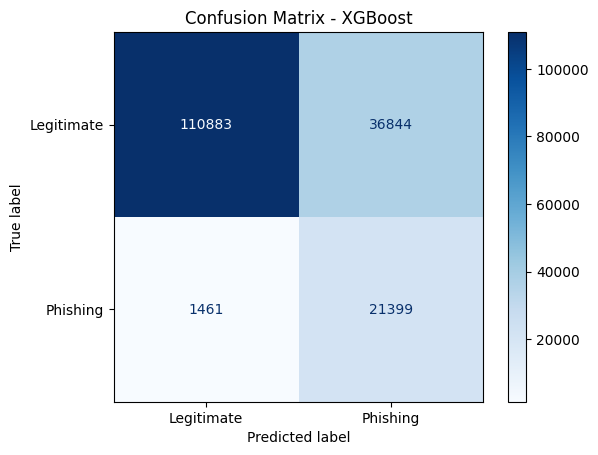

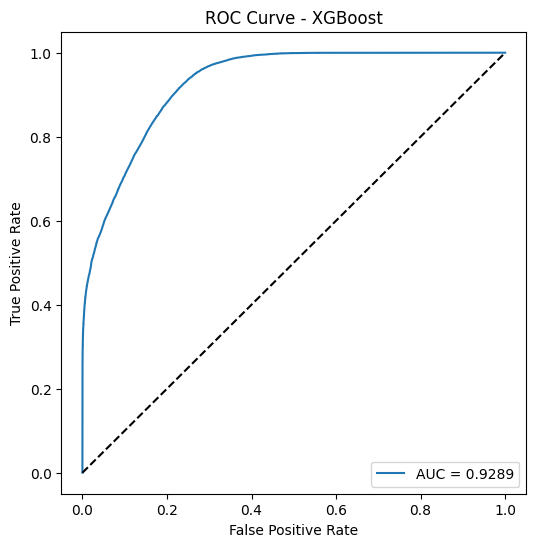

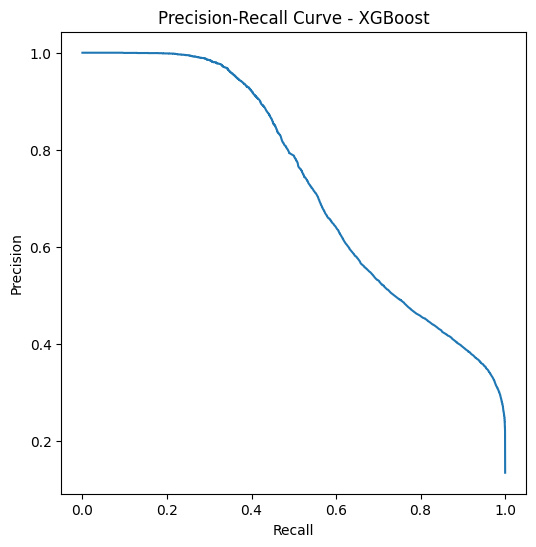

AUC Score: 0.9289
Evaluation plots saved successfully!


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# ==========================================
# ADDITIONAL MODEL EVALUATION - XGBOOST
# ==========================================

# Get prediction probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, xgb_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------
# ROC Curve
# -------------------------------
fpr, tpr, _ = roc_curve(y_test, xgb_probs)
auc = roc_auc_score(y_test, xgb_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------
# Precision-Recall Curve
# -------------------------------
precision, recall, _ = precision_recall_curve(y_test, xgb_probs)

plt.figure(figsize=(6,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.savefig("precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"AUC Score: {auc:.4f}")
print("Evaluation plots saved successfully!")

# **AI Analysis**

Initializing SHAP (SHapley Additive exPlanations)...


Analyzing the XGBoost Model's brain...

Generating SHAP Summary Plot for the Research Paper...
Look at the plot below:
- Features at the TOP are the most important for detecting phishing.
- RED dots mean a HIGH value for that feature (e.g., lots of hyphens).
- Dots pushed to the RIGHT (positive SHAP value) pushed the model to predict 'Phishing'.


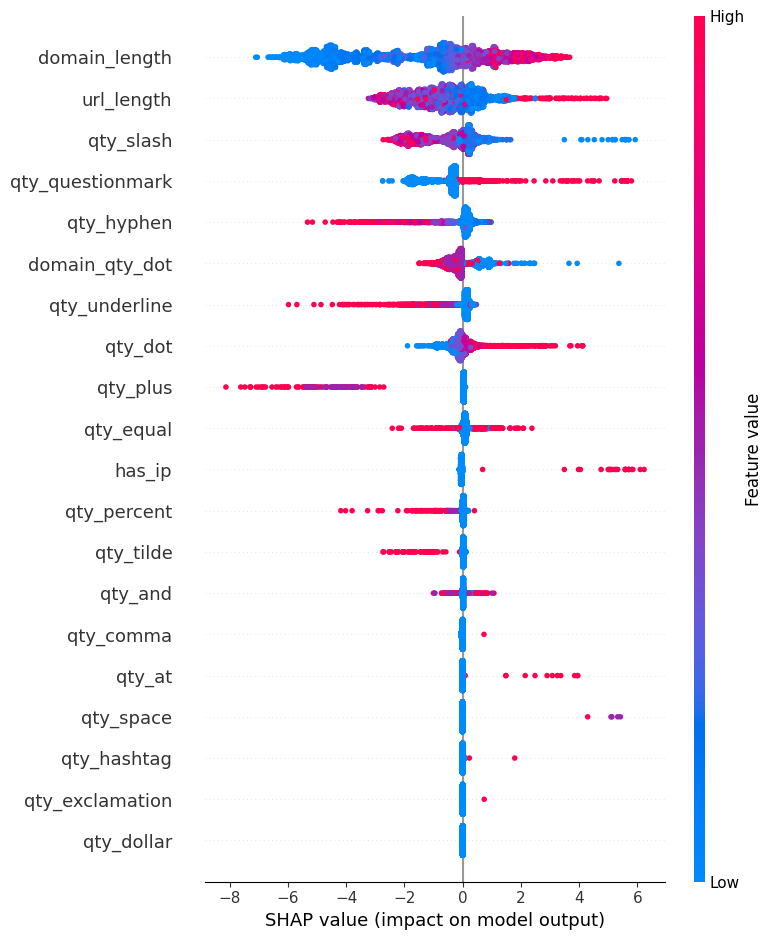


SUCCESS: 'shap_summary_plot.png' saved to Colab files!


In [9]:
import shap
import matplotlib.pyplot as plt

print("Initializing SHAP (SHapley Additive exPlanations)...")
# Initialize JavaScript visualizations in Colab
shap.initjs()

# We use the TreeExplainer because XGBoost is a tree-based model
print("Analyzing the XGBoost Model's brain...")
explainer = shap.TreeExplainer(xgb_model)

# SHAP calculation is very computationally heavy.
# We will use a random sample of 5,000 URLs from our test set to generate the plot quickly.
X_test_sample = X_test.sample(n=5000, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print("\nGenerating SHAP Summary Plot for the Research Paper...")
print("Look at the plot below:")
print("- Features at the TOP are the most important for detecting phishing.")
print("- RED dots mean a HIGH value for that feature (e.g., lots of hyphens).")
print("- Dots pushed to the RIGHT (positive SHAP value) pushed the model to predict 'Phishing'.")

# Create the plot and adjust the size for a good screenshot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)

# Save the plot as a high-res image so you can put it straight into your IEEE paper
plt.savefig('shap_summary_plot.png', bbox_inches='tight', dpi=300)
plt.show()

print("\nSUCCESS: 'shap_summary_plot.png' saved to Colab files!")

In [10]:
import pandas as pd

# Load the dataset directly from the CSV you already generated
final_ml_dataset = pd.read_csv('extracted_features_dataset.csv')

# 1. Satisfy the df.info() requirement
print("--- DATASET ARCHITECTURE (df.info) ---")
final_ml_dataset.info()

# 2. Extract the Top 15 Most Significant Features directly from the XGBoost Brain
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance Weight': xgb_model.feature_importances_
}).sort_values(by='Importance Weight', ascending=False)

print("\n--- TOP 15 MOST SIGNIFICANT THREAT INDICATORS ---")
print(feature_importances.head(15))

--- DATASET ARCHITECTURE (df.info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852933 entries, 0 to 852932
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   url               852933 non-null  object 
 1   label             852933 non-null  float64
 2   url_length        852933 non-null  int64  
 3   qty_dot           852933 non-null  int64  
 4   qty_hyphen        852933 non-null  int64  
 5   qty_underline     852933 non-null  int64  
 6   qty_slash         852933 non-null  int64  
 7   qty_questionmark  852933 non-null  int64  
 8   qty_equal         852933 non-null  int64  
 9   qty_at            852933 non-null  int64  
 10  qty_and           852933 non-null  int64  
 11  qty_exclamation   852933 non-null  int64  
 12  qty_space         852933 non-null  int64  
 13  qty_tilde         852933 non-null  int64  
 14  qty_comma         852933 non-null  int64  
 15  qty_plus          852933 non-

In [11]:
import joblib

# Save the trained XGBoost model to a file
print("Exporting XGBoost model...")
joblib.dump(xgb_model, 'xgboost_phishing_model.pkl')
print("SUCCESS: 'xgboost_phishing_model.pkl' created!")

Exporting XGBoost model...
SUCCESS: 'xgboost_phishing_model.pkl' created!


# **TensorFlow LSTM Training**

In [12]:
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

print(f"TensorFlow Version: {tf.__version__}")
print("Checking for GPU availability...")
print("GPU is", "AVAILABLE" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

# ==========================================
# 1. LOAD & PREPARE DATA
# ==========================================
print("\nLoading Master Dataset...")
df = pd.read_csv('master_url_dataset.csv')
df['url'] = df['url'].astype(str)

urls = df['url'].values
labels = df['label'].values

# ==========================================
# 2. CHARACTER-LEVEL TOKENIZATION
# ==========================================
print("Tokenizing URLs at the character level...")
# We use char_level=True because words don't matter in a URL, the exact character sequence does.
# We limit to the top 100 most frequent characters (covers all English alphanumerics + symbols)
max_chars = 100
tokenizer = Tokenizer(num_words=max_chars, char_level=True, lower=True)
tokenizer.fit_on_texts(urls)

# Convert URLs to integer sequences (e.g., 'a' -> 1, '/' -> 5)
sequences = tokenizer.texts_to_sequences(urls)

# Pad sequences so they are all exactly the same length for the neural network
max_url_length = 150
print(f"Padding sequences to {max_url_length} characters...")
X = pad_sequences(sequences, maxlen=max_url_length, padding='post', truncating='post')
y = np.array(labels)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 3. BUILD THE NEURAL NETWORK ARCHITECTURE
# ==========================================
print("\nCompiling LSTM Architecture...")
model = Sequential([
    # Embedding layer maps integer character codes to dense mathematical vectors
    Embedding(input_dim=max_chars, output_dim=32, input_length=max_url_length),

    # Bidirectional LSTM reads the URL forwards AND backwards to catch obfuscation
    Bidirectional(LSTM(64, return_sequences=False)),

    # Dropout prevents overfitting (stops the model from just memorizing the dataset)
    Dropout(0.5),

    # Dense hidden layer to process the LSTM output
    Dense(32, activation='relu'),
    Dropout(0.5),

    # Final output layer: Sigmoid squashes output between 0 (Safe) and 1 (Phishing)
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ==========================================
# 4. TRAINING THE MODEL
# ==========================================
print("\nCommencing Training Phase...")
# EarlyStopping aborts training if the model stops improving, saving time and preventing overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# ==========================================
# 5. EVALUATION & EXPORT
# ==========================================
print("\nEvaluating Model on Test Set...")
loss, accuracy = model.evaluate(X_test, y_test)
print(f"LSTM Test Accuracy: {accuracy * 100:.2f}%")

print("\nExporting Artifacts for Flask Backend...")
# Save the model
model.save('phishing_lstm.h5')

# CRITICAL: We MUST save the tokenizer. The Flask backend needs the exact same
# character-to-integer dictionary to process live URLs correctly.
with open('char_tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("SUCCESS: 'phishing_lstm.h5' and 'char_tokenizer.pkl' generated.")

TensorFlow Version: 2.20.0
Checking for GPU availability...
GPU is AVAILABLE

Loading Master Dataset...
Tokenizing URLs at the character level...
Padding sequences to 150 characters...

Compiling LSTM Architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Commencing Training Phase...
Epoch 1/10
5331/5331 ━━━━━━━━━━━━━━━━━━━━ 104s 18ms/step - accuracy: 0.9452 - loss: 0.1474 - val_accuracy: 0.9590 - val_loss: 0.1053
Epoch 2/10
5331/5331 ━━━━━━━━━━━━━━━━━━━━ 95s 18ms/step - accuracy: 0.9662 - loss: 0.0955 - val_accuracy: 0.9716 - val_loss: 0.0772
Epoch 3/10
5331/5331 ━━━━━━━━━━━━━━━━━━━━ 143s 18ms/step - accuracy: 0.9726 - loss: 0.0779 - val_accuracy: 0.9761 - val_loss: 0.0682
Epoch 4/10
5331/5331 ━━━━━━━━━━━━━━━━━━━━ 96s 18ms/step - accuracy: 0.9768 - loss: 0.0673 - val_accuracy: 0.9785 - val_loss: 0.0592
Epoch 5/10
5331/5331 ━━━━━━━━━━━━━━━━━━━━ 96s 18ms/step - accuracy: 0.9798 - loss: 0.0595 - val_accuracy: 0.9814 - val_loss: 0.0543
Epoch 6/10
5331/5331 ━━━━━━━━━━━━━━━━━━━━ 95s 18ms/step - accuracy: 0.9818 - loss: 0.0545 - val_accuracy: 0.9834 - val_loss: 0.0491
Epoch 7/10
5331/5331 ━━━━━━━━━━━━━━━━━━━━ 96s 18ms/step - accuracy: 0.9833 - loss: 0.0500 - val_accuracy: 0.9837 - val_loss: 0.0476
Epoch 8/10
5331/5331 ━━━━━━━━━━━━━━━━━━━━ 96

LSTM Test Accuracy: 98.55%

Exporting Artifacts for Flask Backend...
SUCCESS: 'phishing_lstm.h5' and 'char_tokenizer.pkl' generated.
